In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import pickle

In [2]:
RANDOM_STATE = 43289

In [3]:
df = pd.read_csv('../data/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Все типы данных корректны, пропусков нет, предобработка не требуется.

# EDA

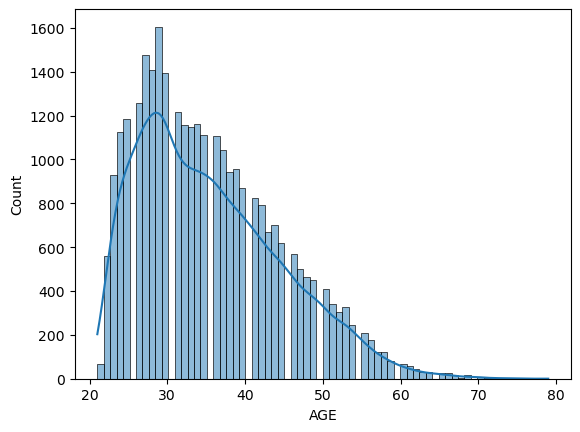

In [5]:
sns.histplot(data=df, x=df['AGE'], kde=True)
plt.show()

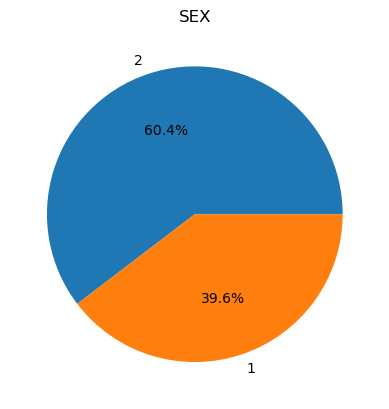

In [6]:
sex_counts = df['SEX'].value_counts()

plt.title('SEX')
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%')
plt.show()

Среди распределения по полу также дисбаланс

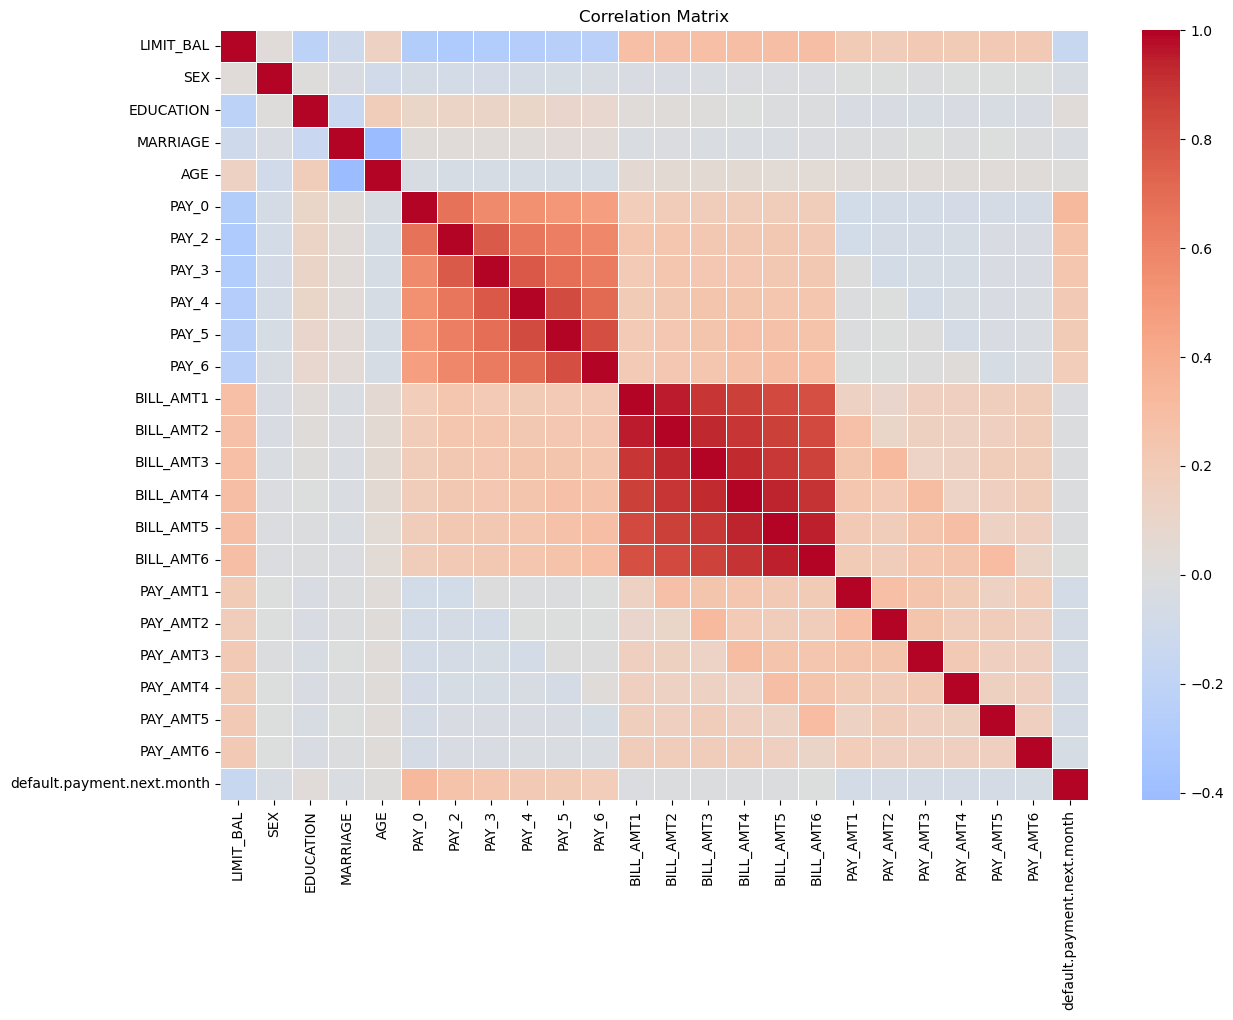

In [7]:
cols = df.select_dtypes('number').drop(columns='ID')

corr = cols.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

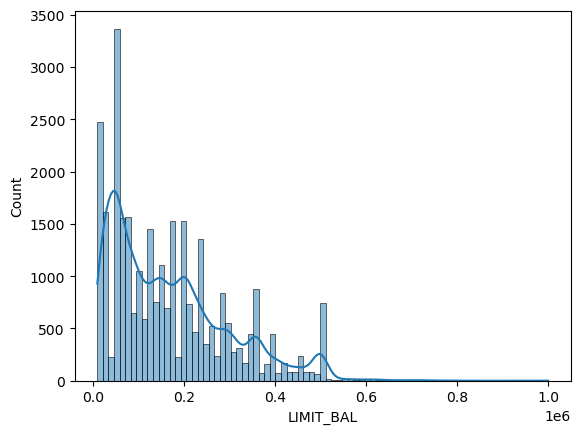

In [8]:
sns.histplot(data=df, x=df['LIMIT_BAL'], kde=True)
plt.show()

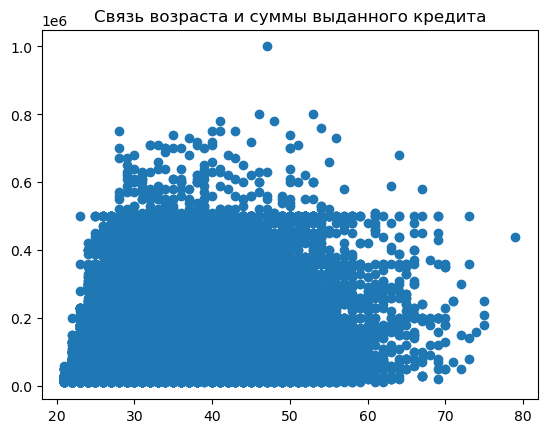

In [9]:
plt.title('Связь возраста и суммы выданного кредита')

plt.scatter(df['AGE'], df['LIMIT_BAL'])
plt.show()

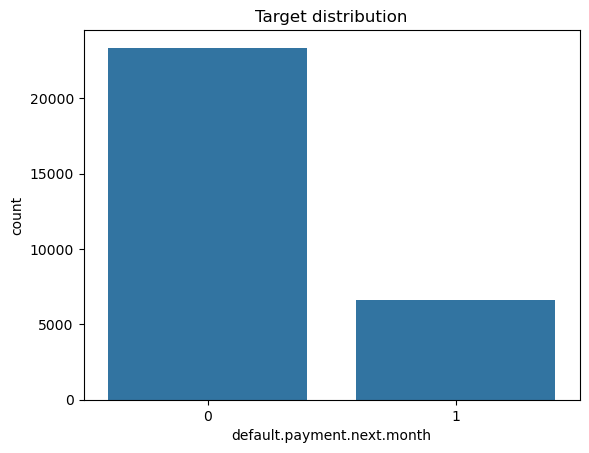

In [10]:
sns.countplot(x='default.payment.next.month', data=df)

plt.title('Target distribution')
plt.show()

Видим, что классы целевой переменной несбалансированы, поэтому будем использовать не accuracy, а f1_score

In [11]:
X = df.drop(columns=['default.payment.next.month', 'ID'])
y = df['default.payment.next.month']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

# Logistic Regression

Т.к мы используем линейную модель, логистическую регрессию, нам необходимо отмасштабировать данные для ускорения сходимости.

Для этого используем StandardScaler из библиотеки sklearn. Сначала обучим скалер на тренировочной выборке, и применим его на тестовую.

In [13]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [14]:
cols_to_transform = X_train.select_dtypes('number').drop(columns=['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']).columns

scaler = StandardScaler()
X_train_scaled[cols_to_transform] = scaler.fit_transform(X_train_scaled[cols_to_transform])
X_test_scaled[cols_to_transform] = scaler.transform(X_test_scaled[cols_to_transform])

class_weight='balanced' т.к таргет несбалансирован

In [15]:
logreg = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,43289
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred = logreg.predict(X_test_scaled)
y_pred_probas = logreg.predict_proba(X_test_scaled)[:,1]

Используем f1 т.к классы несбалансированы и accuracy может сильно завышаться.

In [17]:
logreg_f1 = f1_score(y_test, y_pred)
logreg_roc_auc = roc_auc_score(y_test, y_pred_probas)

print(f'LogisticRegression F1-score: {round(logreg_f1, 3)}')
print(f'LogisticRegression Roc-Auc score: {round(logreg_roc_auc, 3)}')

LogisticRegression F1-score: 0.46
LogisticRegression Roc-Auc score: 0.704


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.71      0.78      4673
           1       0.37      0.61      0.46      1327

    accuracy                           0.69      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.75      0.69      0.71      6000



Как видим, логистическая регрессия показала базовый, но не лучший результат. Модель хуже предсказывает класс 1, что достаточно критично в рамках задачи.

# DecisionTreeClassifier

Сетка гиперпараметров для подбора

In [19]:

tree = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

Для подбора гиперпараметров используем GridSearchCV, т.к обучение DecisionTreeClassifier не слишком тяжелый процесс, и перебор всех вариантов не займет много времени

In [20]:
grid = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

Обучаем множество моделей на сетке гиперпараметров и выбираем лучшую

In [21]:
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best score: {grid.best_score_}")

tree_clf = grid.best_estimator_

Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score: 0.5250603860859526


In [22]:
tree_clf_pred = tree_clf.predict(X_test)
tree_clf_pred_probas = tree_clf.predict_proba(X_test)[:,1]

In [23]:
tree_f1 = f1_score(y_test, tree_clf_pred)
tree_roc_auc = roc_auc_score(y_test, tree_clf_pred_probas)

print(f'DecisionTree F1-score: {round(tree_f1, 3)}')
print(f'DecisionTree Roc-Auc score: {round(tree_roc_auc, 3)}')

DecisionTree F1-score: 0.516
DecisionTree Roc-Auc score: 0.755


In [24]:
print(classification_report(y_test, tree_clf_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.48      0.56      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.77      0.77      6000



Такая же ситуация, как и с LogisticRegression. Результаты несколько выше, однако f1 score в 0.52 всё ещё считается низким, а также наблюдаются проблемы с предсказанием класса 1.

# RandomForestClassifier

Так как прошлые модели показывали достаточно низкие результаты, имеет смысл взять более крупную и тяжелую модель, обладающую лучшей обобщающей способностью.
Будем использовать бэггинг: RandomForestClassifier

In [25]:
forest_clf = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

Для подбора гиперпараметров будем использовать RandomizedSearchCV, так как перебор всех вариантов по сетке занял бы слишком много времени.

In [26]:
random_search = RandomizedSearchCV(
    estimator=forest_clf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5}
Best score: 0.5445366619941918


Выбор лучшей модели

In [27]:
forest_clf = random_search.best_estimator_

forest_clf_pred = forest_clf.predict(X_test)
forest_clf_pred_proba = forest_clf.predict_proba(X_test)[:, 1]

In [28]:
forest_clf_f1 = f1_score(forest_clf_pred, y_test)
forest_clf_roc_auc = forest_clf.predict_proba(X_test)[:, 1]

print(f'RandomForestClassifier F1-score: {round(logreg_f1, 3)}')
print(f'RandomForestClassifier Roc-Auc score: {round(logreg_roc_auc, 3)}')

RandomForestClassifier F1-score: 0.46
RandomForestClassifier Roc-Auc score: 0.704


In [29]:
print(classification_report(y_test, forest_clf_pred))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.50      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.69      6000
weighted avg       0.79      0.78      0.78      6000



По какой-то причине общий f1-score у RandomForestClassifier даже ниже, чем у DecisionTreeClassifier. 

Однако модель чуть лучше предсказывает класс 1, чем предыдущие модели. 

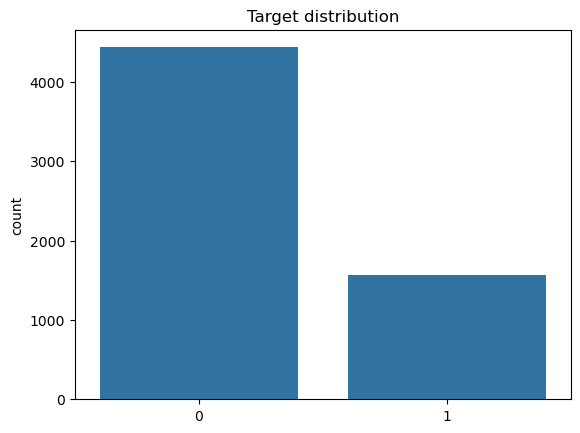

In [30]:
sns.countplot(x=forest_clf_pred)

plt.title('Target distribution')
plt.show()

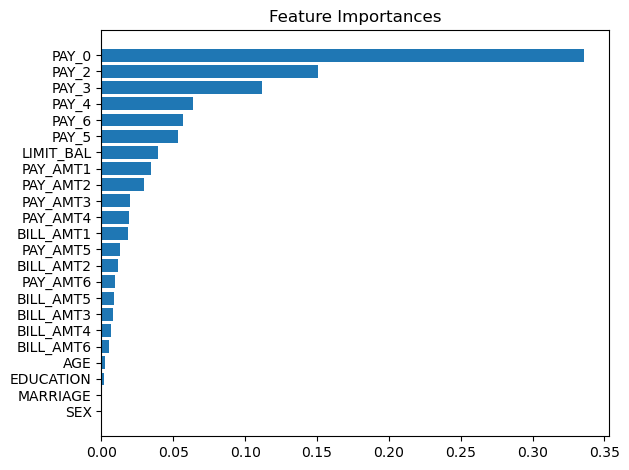

In [31]:
importances = forest_clf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)

plt.figure()
plt.title("Feature Importances")

plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), feature_names[indices])

plt.tight_layout()
plt.show()

Самые важные признаки - история просрочек. Далее по важности идет лимит по кредитке, а также сколько платит клиент.

Самые бесполезные признаки - AGE, EDUCATION, MARRIAG, SEX. В дальнейшем для оптимизации сервиса можно убрать эти признаки из модели.

Сохраняем названия признаков, модель и версию для дальнейшего использования в сервисе

In [32]:
to_load = {
    'model': forest_clf,
    'features': feature_names.tolist(),
    'model_version': 'v1'
}

with open("../models/model.pkl", "wb") as f:
    pickle.dump(to_load, f)

In [33]:
feature_names.tolist()

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [35]:
with open('../models/model.pkl', 'rb') as f:
    model_package = pickle.load(f)

In [ ]:
model_package

,n_estimators,300
,criterion,'gini'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
